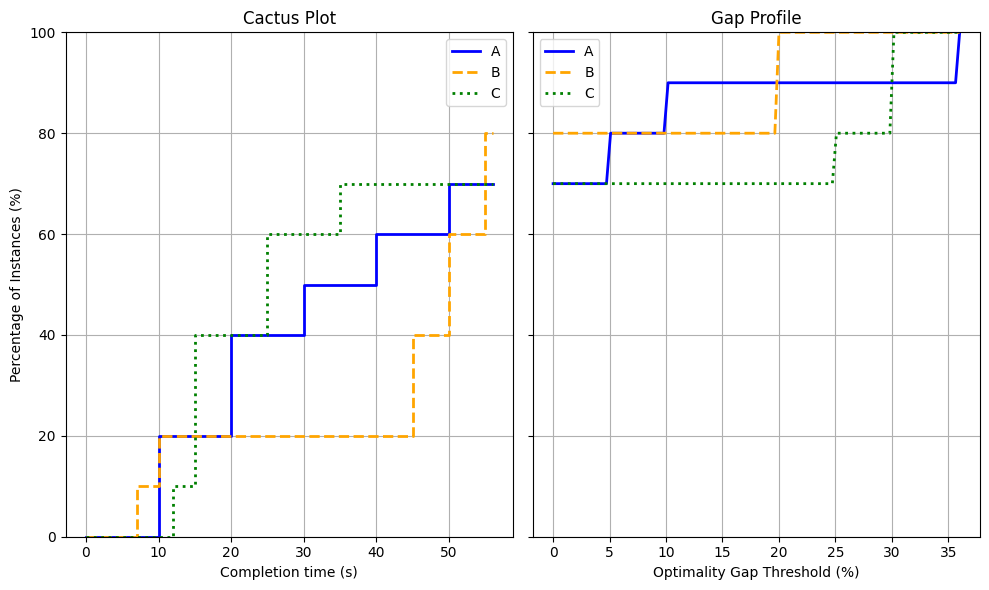

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
instances = [
    {"A": {"Time": np.inf, "Gap": 5},  "B": {"Time": 10,     "Gap": 0},  "C": {"Time": 15,     "Gap": 0}},
    {"A": {"Time": 30,     "Gap": 0},  "B": {"Time": 7,      "Gap": 0},  "C": {"Time": 12,     "Gap": 0}},
    {"A": {"Time": 40,     "Gap": 0},  "B": {"Time": 45,     "Gap": 0},  "C": {"Time": 35,     "Gap": 0}},
    {"A": {"Time": np.inf, "Gap": 36}, "B": {"Time": 55,     "Gap": 0},  "C": {"Time": np.inf, "Gap": 30}},
    {"A": {"Time": 10,     "Gap": 0},  "B": {"Time": np.inf, "Gap": 20}, "C": {"Time": 15,     "Gap": 0}},
    {"A": {"Time": 20,     "Gap": 0},  "B": {"Time": 50,     "Gap": 0},  "C": {"Time": 25,     "Gap": 0}},
    {"A": {"Time": np.inf, "Gap": 10}, "B": {"Time": 45,     "Gap": 0},  "C": {"Time": np.inf, "Gap": 25}},
    {"A": {"Time": 50,     "Gap": 0},  "B": {"Time": 55,     "Gap": 0},  "C": {"Time": np.inf, "Gap": 30}},
    {"A": {"Time": 10,     "Gap": 0},  "B": {"Time": np.inf, "Gap": 20}, "C": {"Time": 15,     "Gap": 0}},
    {"A": {"Time": 20,     "Gap": 0},  "B": {"Time": 50,     "Gap": 0},  "C": {"Time": 25,     "Gap": 0}},
]

# Total number of instances
total_instances = len(instances)

# Extract and sort times for each algorithm
times_A = sorted(instance["A"]["Time"] for instance in instances if instance["A"]["Time"] != np.inf)
times_B = sorted(instance["B"]["Time"] for instance in instances if instance["B"]["Time"] != np.inf)
times_C = sorted(instance["C"]["Time"] for instance in instances if instance["C"]["Time"] != np.inf)

# Cumulative percentage of solved instances over time
cumulative_A = (np.arange(1, len(times_A) + 1) / total_instances) * 100
cumulative_B = (np.arange(1, len(times_B) + 1) / total_instances) * 100
cumulative_C = (np.arange(1, len(times_C) + 1) / total_instances) * 100

# Add a final point for unsolved instances (at max time + 1)
max_time = max(max(times_A + [0]), max(times_B + [0]), max(times_C + [0])) + 1
times_A.append(max_time)
times_B.append(max_time)
times_C.append(max_time)
cumulative_A = np.append(cumulative_A, cumulative_A[-1])
cumulative_B = np.append(cumulative_B, cumulative_B[-1])
cumulative_C = np.append(cumulative_C, cumulative_C[-1])

# Gaps for unsolved instances
gaps_A = sorted(instance["A"]["Gap"] for instance in instances)
gaps_B = sorted(instance["B"]["Gap"] for instance in instances)
gaps_C = sorted(instance["C"]["Gap"] for instance in instances)

# Gap thresholds
gap_thresholds = np.linspace(0, max(max(gaps_A + [0]), max(gaps_B + [0]), max(gaps_C + [0])), 100)



cumulative_gaps_A = [(np.sum(np.array(gaps_A) <= threshold) / total_instances) * 100 for threshold in gap_thresholds]
cumulative_gaps_B = [(np.sum(np.array(gaps_B) <= threshold) / total_instances) * 100 for threshold in gap_thresholds]
cumulative_gaps_C = [(np.sum(np.array(gaps_C) <= threshold) / total_instances) * 100 for threshold in gap_thresholds]

# Create the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), sharey=True, gridspec_kw={'width_ratios': [1, 1]})

# Cactus Plot
ax1.step([0] + times_A, [0] + list(cumulative_A), where='post', label='A', color='blue', linestyle='-', linewidth=2)
ax1.step([0] + times_B, [0] + list(cumulative_B), where='post', label='B', color='orange', linestyle='--', linewidth=2)
ax1.step([0] + times_C, [0] + list(cumulative_C), where='post', label='C', color='green', linestyle=':', linewidth=2)
ax1.set_xlabel('Completion time (s)')
ax1.set_ylabel('Percentage of Instances (%)')
ax1.set_title('Cactus Plot')
ax1.legend()
ax1.grid(True)
ax1.set_ylim(0, 100)

# Gap Profile
ax2.plot(gap_thresholds, cumulative_gaps_A, label='A', color='blue', linestyle='-', linewidth=2)
ax2.plot(gap_thresholds, cumulative_gaps_B, label='B', color='orange', linestyle='--', linewidth=2)
ax2.plot(gap_thresholds, cumulative_gaps_C, label='C', color='green', linestyle=':', linewidth=2)
ax2.set_xlabel('Optimality Gap Threshold (%)')
ax2.set_title('Gap Profile')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


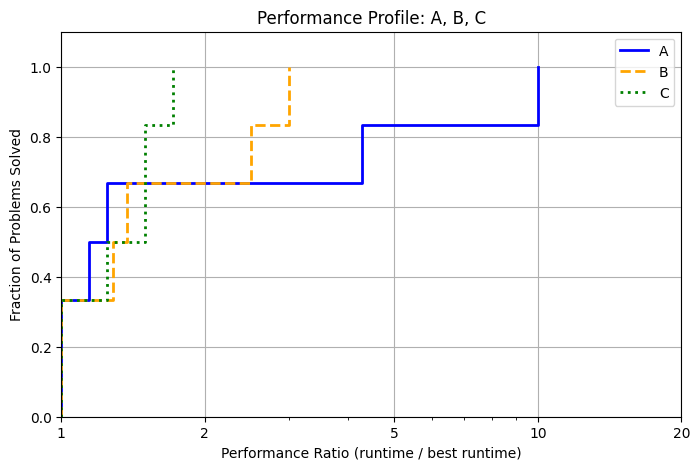

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

# Runtime data for A, B, C (each row is an instance)
A = [100, 30, 40, 50, 10, 20]
B = [10, 7, 45, 55, 30, 50]
C = [15, 12, 35, 40, 15, 25]

# Total number of instances
total_instances = len(A)

# For each instance, find the best runtime
best_runtimes = [min(a, b, c) for a, b, c in zip(A, B, C)]

# Compute performance ratios for each algorithm
ratio_A = [a / best if best != 0 else np.inf for a, best in zip(A, best_runtimes)]
ratio_B = [b / best if best != 0 else np.inf for b, best in zip(B, best_runtimes)]
ratio_C = [c / best if best != 0 else np.inf for c, best in zip(C, best_runtimes)]

# Sort performance ratios
sorted_A = sorted(ratio_A)
sorted_B = sorted(ratio_B)
sorted_C = sorted(ratio_C)

sorted_A = [r for r in sorted_A if r != np.inf]
sorted_B = [r for r in sorted_B if r != np.inf]
sorted_C = [r for r in sorted_C if r != np.inf]

# Compute the fraction of problems solved for each algorithm
fraction_A = [(i + 1) / total_instances for i in range(len(sorted_A))]
fraction_B = [(i + 1) / total_instances for i in range(len(sorted_B))]
fraction_C = [(i + 1) / total_instances for i in range(len(sorted_C))]

# Create the plot
plt.figure(figsize=(8, 5))

# Plot performance profiles
plt.step([1] + sorted_A, [0] + fraction_A, where='post', label='A', color='blue', linestyle='-', linewidth=2)
plt.step([1] + sorted_B, [0] + fraction_B, where='post', label='B', color='orange', linestyle='--', linewidth=2)
plt.step([1] + sorted_C, [0] + fraction_C, where='post', label='C', color='green', linestyle=':', linewidth=2)

# Labels and title
plt.xlabel('Performance Ratio (runtime / best runtime)')
plt.ylabel('Fraction of Problems Solved')
plt.title('Performance Profile: A, B, C')

# Set x-axis to log scale and format the tick labels to avoid scientific notation
plt.xscale('log')
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.gca().xaxis.set_ticks([1, 2, 5, 10, 20, 50])
plt.xlim(1, 20)
plt.ylim(0, 1.1)

plt.legend()
plt.grid(True)

# Show plot
plt.show()


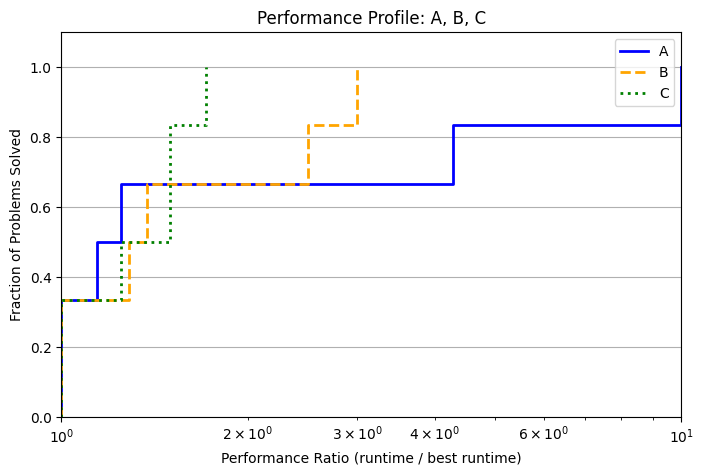

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Runtime data for A, B, C (each row is an instance)
A = [100, 30, 40, 50, 10, 20]
B = [10, 7, 45, 55, 30, 50]
C = [15, 12, 35, 40, 15, 25]

# Total number of instances
total_instances = len(A)

# For each instance, find the best runtime
best_runtimes = [min(a, b, c) for a, b, c in zip(A, B, C)]

# Compute performance ratios for each algorithm
ratio_A = [a / best if best != 0 else np.inf for a, best in zip(A, best_runtimes)]
ratio_B = [b / best if best != 0 else np.inf for b, best in zip(B, best_runtimes)]
ratio_C = [c / best if best != 0 else np.inf for c, best in zip(C, best_runtimes)]

# Sort performance ratios
sorted_A = sorted(ratio_A)
sorted_B = sorted(ratio_B)
sorted_C = sorted(ratio_C)

# Compute the fraction of problems solved for each algorithm
fraction_A = [(i + 1) / total_instances for i in range(len([r for r in ratio_A if r != np.inf]))]
fraction_B = [(i + 1) / total_instances for i in range(len([r for r in ratio_B if r != np.inf]))]
fraction_C = [(i + 1) / total_instances for i in range(len([r for r in ratio_C if r != np.inf]))]

# Add a point at infinity for unsolved problems
sorted_A = [r for r in sorted_A if r != np.inf] + [np.inf]
sorted_B = [r for r in sorted_B if r != np.inf] + [np.inf]
sorted_C = [r for r in sorted_C if r != np.inf] + [np.inf]
fraction_A = [(i + 1) / total_instances for i in range(len(sorted_A))]
fraction_B = [(i + 1) / total_instances for i in range(len(sorted_B))]
fraction_C = [(i + 1) / total_instances for i in range(len(sorted_C))]

# Create the plot
plt.figure(figsize=(8, 5))

# Plot performance profiles
plt.step([1] + sorted_A, [0] + fraction_A, where='post', label='A', color='blue', linestyle='-', linewidth=2)
plt.step([1] + sorted_B, [0] + fraction_B, where='post', label='B', color='orange', linestyle='--', linewidth=2)
plt.step([1] + sorted_C, [0] + fraction_C, where='post', label='C', color='green', linestyle=':', linewidth=2)

# Labels and title
plt.xlabel('Performance Ratio (runtime / best runtime)')
plt.ylabel('Fraction of Problems Solved')
plt.title('Performance Profile: A, B, C')
plt.xscale('log')
plt.xlim(1, 10)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True)

# Show plot
plt.show()


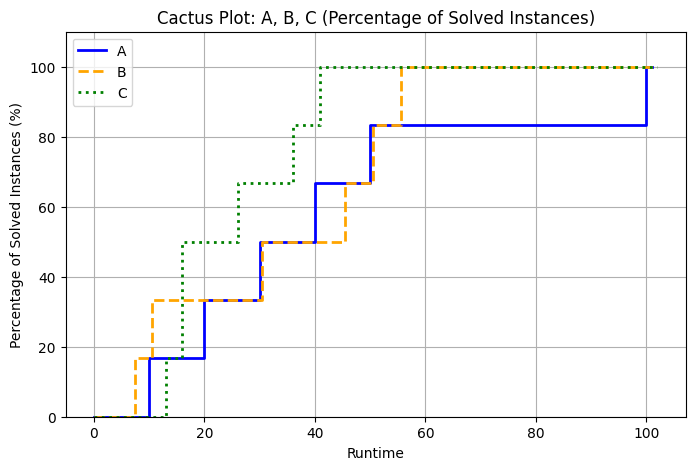

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Runtime data for A, B, C (each row is an instance)
A = [100, 30, 40, 50, 10, 20]
B = [10, 7, 45, 55, 30, 50]
C = [15, 12, 35, 40, 15, 25]

# Sort runtimes for each algorithm
sorted_A = sorted(A)
sorted_B = sorted(B)
sorted_C = sorted(C)

# Total number of instances
total_instances = len(A)

# Cumulative percentage of solved instances over time
cumulative_A = (np.arange(1, len(sorted_A) + 1) / total_instances) * 100
cumulative_B = (np.arange(1, len(sorted_B) + 1) / total_instances) * 100
cumulative_C = (np.arange(1, len(sorted_C) + 1) / total_instances) * 100

# Add a final point for unsolved instances (at max time + 1)
max_time = max(max(A), max(B), max(C)) + 1
sorted_A.append(max_time)
sorted_B.append(max_time)
sorted_C.append(max_time)
cumulative_A = np.append(cumulative_A, cumulative_A[-1])
cumulative_B = np.append(cumulative_B, cumulative_B[-1])
cumulative_C = np.append(cumulative_C, cumulative_C[-1])

# Create the plot
plt.figure(figsize=(8, 5))

# Plot with small horizontal offsets for clarity
plt.step([0] + sorted_A, [0] + list(cumulative_A), where='post', label='A', color='blue', linestyle='-', linewidth=2)
plt.step([0] + [t + 0.5 for t in sorted_B], [0] + list(cumulative_B), where='post', label='B', color='orange', linestyle='--', linewidth=2)
plt.step([0] + [t + 1 for t in sorted_C], [0] + list(cumulative_C), where='post', label='C', color='green', linestyle=':', linewidth=2)

# Labels and title
plt.xlabel('Runtime')
plt.ylabel('Percentage of Solved Instances (%)')
plt.title('Cactus Plot: A, B, C (Percentage of Solved Instances)')
plt.ylim(0, 110)  # Ensure 100% is visible
plt.legend()
plt.grid(True)

# Show plot
plt.show()


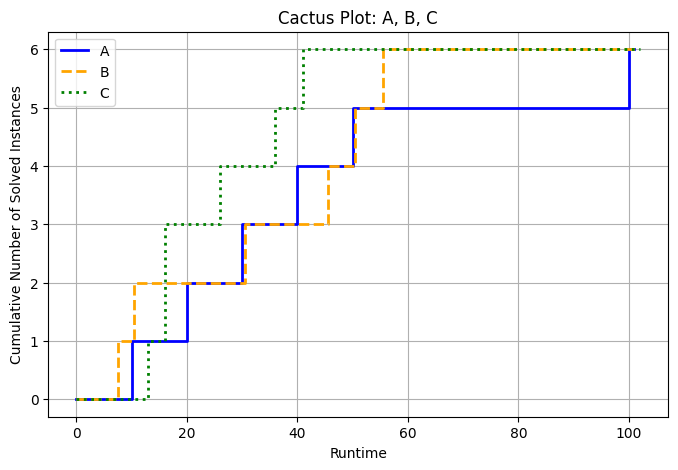

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Runtime data for A, B, C (each row is an instance)
A = [100, 30, 40, 50, 10, 20]
B = [10, 7, 45, 55, 30, 50]
C = [15, 12, 35, 40, 15, 25]

# Sort runtimes for each algorithm
sorted_A = sorted(A)
sorted_B = sorted(B)
sorted_C = sorted(C)

# Cumulative number of solved instances over time
cumulative_A = np.arange(1, len(sorted_A) + 1)
cumulative_B = np.arange(1, len(sorted_B) + 1)
cumulative_C = np.arange(1, len(sorted_C) + 1)

# Add a final point for unsolved instances (at max time + 1)
max_time = max(max(A), max(B), max(C)) + 1
sorted_A.append(max_time)
sorted_B.append(max_time)
sorted_C.append(max_time)
cumulative_A = np.append(cumulative_A, cumulative_A[-1])
cumulative_B = np.append(cumulative_B, cumulative_B[-1])
cumulative_C = np.append(cumulative_C, cumulative_C[-1])

# Create the plot
plt.figure(figsize=(8, 5))

# Plot with small horizontal offsets for clarity
plt.step([0] + sorted_A, [0] + list(cumulative_A), where='post', label='A', color='blue', linestyle='-', linewidth=2)
plt.step([0] + [t + 0.5 for t in sorted_B], [0] + list(cumulative_B), where='post', label='B', color='orange', linestyle='--', linewidth=2)
plt.step([0] + [t + 1 for t in sorted_C], [0] + list(cumulative_C), where='post', label='C', color='green', linestyle=':', linewidth=2)

# Labels and title
plt.xlabel('Runtime')
plt.ylabel('Cumulative Number of Solved Instances')
plt.title('Cactus Plot: A, B, C')
plt.legend()
plt.grid(True)

# Show plot
plt.show()


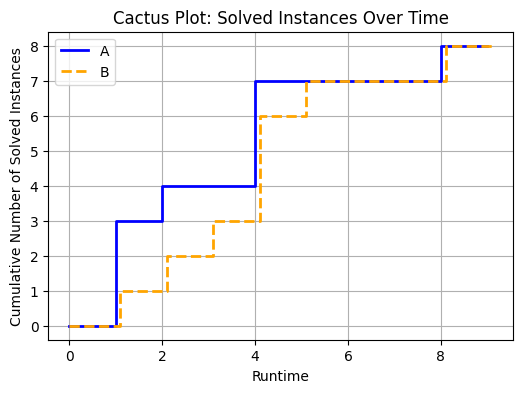

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Runtime data (TO = not solved)
A = [1, 2, None, 8, 4, 1, 1, 4, 4, None]
B = [4, 8, 3, 4, 1, 5, 4, 2, None, None]

# Extract solved runtimes (ignore None/TO)
solved_A = sorted([t for t in A if t is not None])
solved_B = sorted([t for t in B if t is not None])

# Cumulative number of solved instances over time
cumulative_A = np.arange(1, len(solved_A) + 1)
cumulative_B = np.arange(1, len(solved_B) + 1)

# Add a final point for unsolved instances (at max time + 1)
max_time = max(max(solved_A + [0]), max(solved_B + [0])) + 1
solved_A.append(max_time)
solved_B.append(max_time)
cumulative_A = np.append(cumulative_A, cumulative_A[-1])
cumulative_B = np.append(cumulative_B, cumulative_B[-1])

# Create the plot
plt.figure(figsize=(6, 4))

# Plot with small horizontal offset for B
plt.step([0] + solved_A, [0] + list(cumulative_A), where='post', label='A', color='blue', linestyle='-', linewidth=2)
plt.step([0] + [t + 0.1 for t in solved_B], [0] + list(cumulative_B), where='post', label='B', color='orange', linestyle='--', linewidth=2)

# Labels and title
plt.xlabel('Runtime')
plt.ylabel('Cumulative Number of Solved Instances')
plt.title('Cactus Plot: Solved Instances Over Time')
plt.legend()
plt.grid(True)

# Show plot
plt.show()


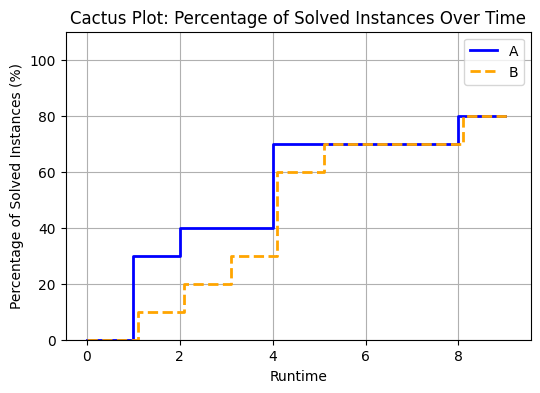

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Runtime data (TO = not solved)
A = [1, 2, None, 8, 4, 1, 1, 4, 4, None]
B = [4, 8, 3, 4, 1, 5, 4, 2, None, None]

# Extract solved runtimes (ignore None/TO)
solved_A = sorted([t for t in A if t is not None])
solved_B = sorted([t for t in B if t is not None])

# Total number of instances
total_instances = 10

# Cumulative number of solved instances over time (as percentage)
cumulative_A = (np.arange(1, len(solved_A) + 1) / total_instances) * 100
cumulative_B = (np.arange(1, len(solved_B) + 1) / total_instances) * 100

# Add a final point for unsolved instances (at max time + 1)
max_time = max(max(solved_A + [0]), max(solved_B + [0])) + 1
solved_A.append(max_time)
solved_B.append(max_time)
cumulative_A = np.append(cumulative_A, cumulative_A[-1])
cumulative_B = np.append(cumulative_B, cumulative_B[-1])

# Create the plot
plt.figure(figsize=(6, 4))

# Plot with small horizontal offset for B
plt.step([0] + solved_A, [0] + list(cumulative_A), where='post', label='A', color='blue', linestyle='-', linewidth=2)
plt.step([0] + [t + 0.1 for t in solved_B], [0] + list(cumulative_B), where='post', label='B', color='orange', linestyle='--', linewidth=2)

# Labels and title
plt.xlabel('Runtime')
plt.ylabel('Percentage of Solved Instances (%)')
plt.title('Cactus Plot: Percentage of Solved Instances Over Time')
plt.ylim(0, 110)  # Ensure 100% is visible
plt.legend()
plt.grid(True)

# Show plot
plt.show()


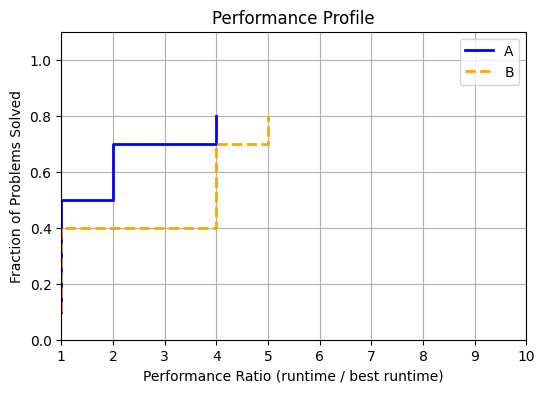

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Runtime data (TO = not solved, set to a large value)
A = [1, 2, np.inf, 8, 4, 1, 1, 4, 4, np.inf]
B = [4, 8, 3, 4, 1, 5, 4, 2, np.inf, np.inf]

# For each instance, find the best runtime
best_runtimes = [min(a, b) for a, b in zip(A, B)]

# Compute performance ratios
ratio_A = [a / b if b != 0 else np.inf for a, b in zip(A, best_runtimes)]
ratio_B = [b / b_best if b_best != 0 else np.inf for b, b_best in zip(B, best_runtimes)]

# Sort performance ratios
sorted_A = sorted(ratio_A)
sorted_B = sorted(ratio_B)

# Compute the fraction of problems solved for each solver
n_problems = len(A)
fraction_A = [(i + 1) / n_problems for i in range(n_problems)]
fraction_B = [(i + 1) / n_problems for i in range(n_problems)]

# Add a point at infinity for unsolved problems
sorted_A = [r for r in sorted_A if r != np.inf] + [np.inf]
sorted_B = [r for r in sorted_B if r != np.inf] + [np.inf]
fraction_A = [(i + 1) / n_problems for i in range(len(sorted_A))]
fraction_B = [(i + 1) / n_problems for i in range(len(sorted_B))]

# Create the plot
plt.figure(figsize=(6, 4))

# Plot performance profiles
plt.step(sorted_A, fraction_A, where='post', label='A', color='blue', linestyle='-', linewidth=2)
plt.step(sorted_B, fraction_B, where='post', label='B', color='orange', linestyle='--', linewidth=2)

# Labels and title
plt.xlabel('Performance Ratio (runtime / best runtime)')
plt.ylabel('Fraction of Problems Solved')
plt.title('Performance Profile')
#plt.xscale('log')
plt.xlim(1, 10)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True)

# Show plot
plt.show()

[np.float64(80.0), np.float64(80.0), np.float64(80.0), np.float64(80.0), np.float64(80.0), np.float64(80.0), np.float64(80.0), np.float64(80.0), np.float64(80.0), np.float64(80.0), np.float64(80.0), np.float64(80.0), np.float64(80.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(90.0), np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0), np.float64(100.0), np.f

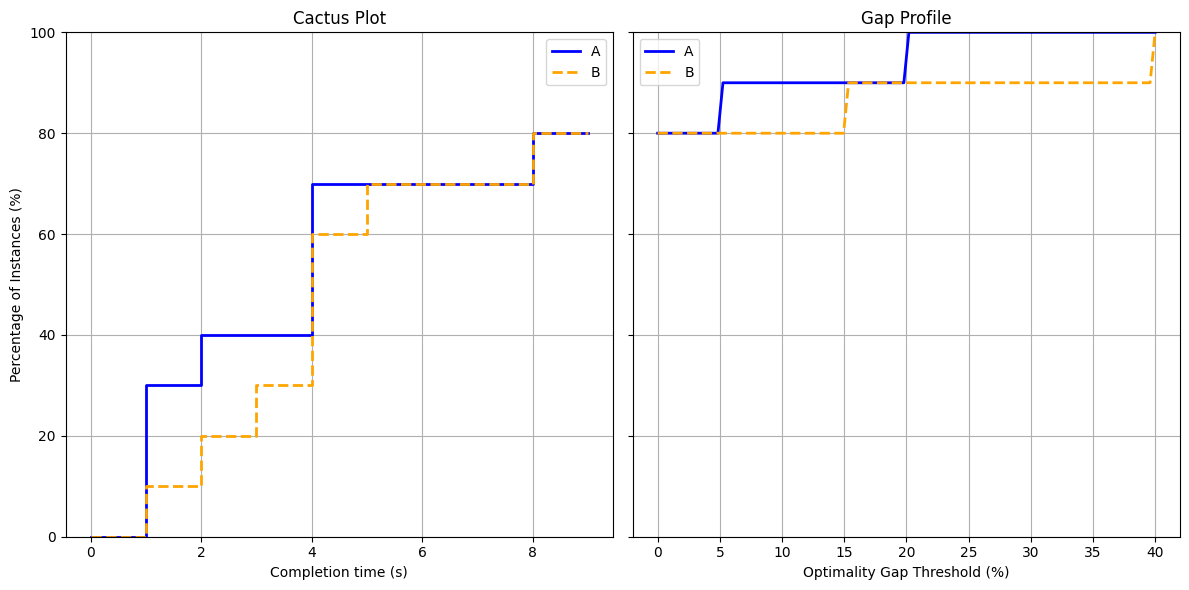

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
instances = [
    {"A": {"Time": 1, "Gap": 0},   "B": {"Time": 4, "Gap": 0}},
    {"A": {"Time": 2, "Gap": 0},   "B": {"Time": 8, "Gap": 0}},
    {"A": {"Time": np.inf, "Gap": 20}, "B": {"Time": 3, "Gap": 0}},
    {"A": {"Time": 8, "Gap": 0},   "B": {"Time": 4, "Gap": 0}},
    {"A": {"Time": 4, "Gap": 0},   "B": {"Time": 1, "Gap": 0}},
    {"A": {"Time": 1, "Gap": 0},   "B": {"Time": 5, "Gap": 0}},
    {"A": {"Time": 1, "Gap": 0},   "B": {"Time": 4, "Gap": 0}},
    {"A": {"Time": 4, "Gap": 0},   "B": {"Time": 2, "Gap": 0}},
    {"A": {"Time": 4, "Gap": 0},   "B": {"Time": np.inf, "Gap": 15}},
    {"A": {"Time": np.inf, "Gap": 5},  "B": {"Time": np.inf, "Gap": 40}},
]

# Total number of instances
total_instances = len(instances)

# Extract and sort times for each algorithm
times_A = sorted(instance["A"]["Time"] for instance in instances if instance["A"]["Time"] != np.inf)
times_B = sorted(instance["B"]["Time"] for instance in instances if instance["B"]["Time"] != np.inf)

# Cumulative percentage of solved instances over time
cumulative_A = (np.arange(1, len(times_A) + 1) / total_instances) * 100
cumulative_B = (np.arange(1, len(times_B) + 1) / total_instances) * 100

# Add a final point for unsolved instances (at max time + 1)
max_time = max(max(times_A + [0]), max(times_B + [0])) + 1
times_A.append(max_time)
times_B.append(max_time)
cumulative_A = np.append(cumulative_A, cumulative_A[-1])
cumulative_B = np.append(cumulative_B, cumulative_B[-1])

# Gaps for unsolved instances
gaps_A = sorted(instance["A"]["Gap"] for instance in instances)
gaps_B = sorted(instance["B"]["Gap"] for instance in instances)

# Gap thresholds
gap_thresholds = np.linspace(0, max(max(gaps_A + [0]), max(gaps_B + [0])), 100)

# Cumulative percentage of instances with gap less than threshold


cumulative_gaps_A = [(np.sum(np.array(gaps_A) <= threshold) / total_instances) * 100 for threshold in gap_thresholds]
cumulative_gaps_B = [(np.sum(np.array(gaps_B) <= threshold) / total_instances) * 100 for threshold in gap_thresholds]

print(cumulative_gaps_A)

# Create the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True, gridspec_kw={'width_ratios': [1, 1]})

# Cactus Plot
ax1.step([0] + times_A, [0] + list(cumulative_A), where='post', label='A', color='blue', linestyle='-', linewidth=2)
ax1.step([0] + times_B, [0] + list(cumulative_B), where='post', label='B', color='orange', linestyle='--', linewidth=2)
ax1.set_xlabel('Completion time (s)')
ax1.set_ylabel('Percentage of Instances (%)')
ax1.set_title('Cactus Plot')
ax1.legend()
ax1.grid(True)
ax1.set_ylim(0, 100)

# Gap Profile
ax2.plot(gap_thresholds, cumulative_gaps_A, label='A', color='blue', linestyle='-', linewidth=2)
ax2.plot(gap_thresholds, cumulative_gaps_B, label='B', color='orange', linestyle='--', linewidth=2)
ax2.set_xlabel('Optimality Gap Threshold (%)')
ax2.set_title('Gap Profile')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()
